# 🏨 Hotel Bookings — Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import itertools
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

## ⚙️ Global Config

In [ ]:
C = {
    "blue"  : "#4C9BE8",
    "coral" : "#F07167",
    "green" : "#52B788",
    "purple": "#9B89C4",
    "orange": "#F4A261",
    "teal"  : "#2EC4B6",
    "bg"    : "#F8F9FA",
    "text"  : "#2D3436",
}

plt.rcParams["figure.dpi"]        = 120
plt.rcParams["figure.figsize"]    = (12, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

MONTH_ORDER = [
    "January", "February", "March",    "April",
    "May",     "June",     "July",     "August",
    "September","October", "November", "December",
]

## 🛠️ Helper Functions

In [ ]:
def section(q, title):
    """Print a clearly visible section header."""
    print("\n" + "=" * 65)
    print(f"  {q} | {title}")
    print("=" * 65)


def style_ax(ax):
    """Apply consistent background / grid style to an Axes object."""
    ax.set_facecolor(C["bg"])
    ax.spines["left"].set_visible(False)
    ax.yaxis.grid(True, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)

## 📂 Load Data

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

df_raw = pd.read_csv("/content/drive/MyDrive/hotel_bookings.csv")
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")

Mounted at /content/drive
Rows: 119,390  |  Columns: 32


## Q1 | Dataset Overview

In [ ]:
section("Q1", "Dataset Overview")

print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]}")

print("\n-- 5 sample rows")
display(df_raw.head())

print("\n-- All column names")

for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2}. {col}")


  Q1 | Dataset Overview
Rows    : 119,390
Columns : 32

-- 5 sample rows


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03



-- All column names
   1. hotel
   2. is_canceled
   3. lead_time
   4. arrival_date_year
   5. arrival_date_month
   6. arrival_date_week_number
   7. arrival_date_day_of_month
   8. stays_in_weekend_nights
   9. stays_in_week_nights
  10. adults
  11. children
  12. babies
  13. meal
  14. country
  15. market_segment
  16. distribution_channel
  17. is_repeated_guest
  18. previous_cancellations
  19. previous_bookings_not_canceled
  20. reserved_room_type
  21. assigned_room_type
  22. booking_changes
  23. deposit_type
  24. agent
  25. company
  26. days_in_waiting_list
  27. customer_type
  28. adr
  29. required_car_parking_spaces
  30. total_of_special_requests
  31. reservation_status
  32. reservation_status_date


## Q2 | Column Understanding

In [ ]:
section("Q2", "Column Understanding")
df_raw.info()


  Q2 | Column Understanding
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  

## Q3 | Data Types Check

In [ ]:
section("Q3", "Data Types Check")
print(df_raw.dtypes.to_string())


  Q3 | Data Types Check
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent    

## Q4 | Missing Values


  Q4 | Missing Values


,Count,Pct%
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


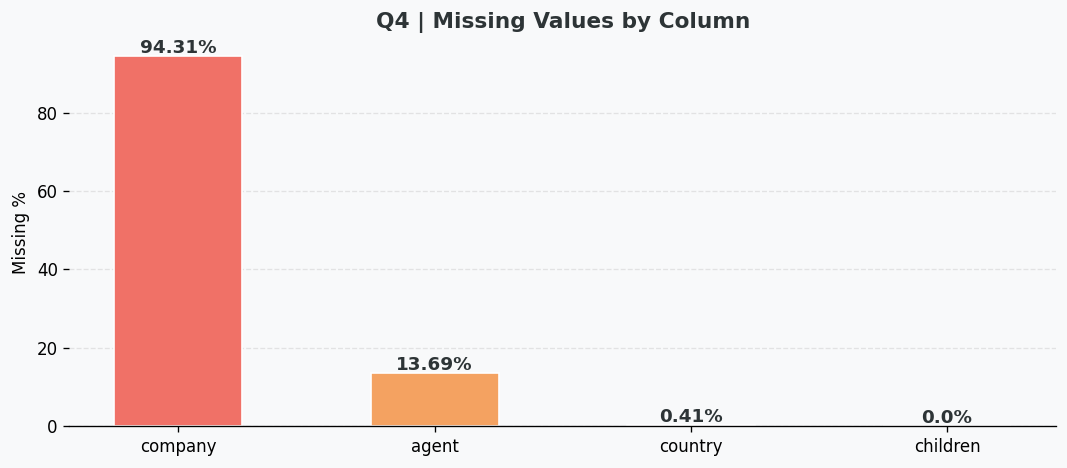

In [ ]:
section("Q4", "Missing Values")

mis       = df_raw.isnull().sum().sort_values(ascending=False)
pct       = (mis / len(df_raw) * 100).round(2)
miss_df   = pd.DataFrame({"Count": mis, "Pct%": pct})
miss_plot = miss_df[miss_df["Count"] > 0]

display(miss_plot)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(C["bg"])
style_ax(ax)

bars = ax.bar(
    miss_plot.index, miss_plot["Pct%"],
    color=[C["coral"], C["orange"], C["blue"], C["purple"]],
    edgecolor="white", width=0.5,
)

for bar, val in zip(bars, miss_plot["Pct%"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val}%",
        ha="center", fontsize=11, fontweight="bold", color=C["text"],
    )

ax.set_title("Q4 | Missing Values by Column", fontsize=13, fontweight="bold", color=C["text"])
ax.set_ylabel("Missing %")
plt.tight_layout()
plt.show()

## Q5 | Missing Values Strategy

In [ ]:
section("Q5", "Missing Handling Plan")

plan = [
    ("company",  "DROP COLUMN",       "94.3% missing -- too sparse"),
    ("agent",    "fillna(0) -> int",  "0 = direct booking"),
    ("children", "fillna(0) -> int",  "only 4 rows; 0 is safe default"),
    ("country",  "fillna(mode=PRT)",  "only 488 rows (0.41%)"),
]

print(f"  {'Column':<12} {'Action':<25} Reason")
print("  " + "-" * 65)
for col, action, reason in plan:
    print(f"  {col:<12} {action:<25} {reason}")


  Q5 | Missing Handling Plan
  Column       Action                    Reason
  -----------------------------------------------------------------
  company      DROP COLUMN               94.3% missing -- too sparse
  agent        fillna(0) -> int          0 = direct booking
  children     fillna(0) -> int          only 4 rows; 0 is safe default
  country      fillna(mode=PRT)          only 488 rows (0.41%)


## Q6 & Q7 | Duplicates

In [ ]:
section("Q6", "Duplicate Rows")
dup = df_raw.duplicated().sum()
print(f"Exact duplicates: {dup:,}  ({dup / len(df_raw) * 100:.1f}% of data)")
display(df_raw[df_raw.duplicated(keep=False)].head(4))

section("Q7", "ID Column")
print("No unique booking-ID column exists.")
print("Decision: drop only exact full-row duplicates.")


  Q6 | Duplicate Rows
Exact duplicates: 31,994  (26.8% of data)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07



  Q7 | ID Column
No unique booking-ID column exists.
Decision: drop only exact full-row duplicates.


## Q8 | Validity Rules

In [ ]:
section("Q8", "Impossible Values")

ch = df_raw["children"].fillna(0)

checks = {
    "adr < 0"       : (df_raw["adr"] < 0).sum(),
    "adr = 0"       : (df_raw["adr"] == 0).sum(),
    "adults = 0"    : (df_raw["adults"] == 0).sum(),
    "total guests=0": ((df_raw["adults"] + ch + df_raw["babies"]) == 0).sum(),
    "total nights=0": ((df_raw["stays_in_weekend_nights"] + df_raw["stays_in_week_nights"]) == 0).sum(),
    "lead_time < 0" : (df_raw["lead_time"] < 0).sum(),
}

print(f"  {'Rule':<30} {'Violations':>12}")
print("  " + "-" * 44)
for rule, count in checks.items():
    flag = "  WARNING" if count > 0 else "  OK"
    print(f"  {rule:<30} {count:>12,}{flag}")


  Q8 | Impossible Values
  Rule                             Violations
  --------------------------------------------
  adr < 0                                   1  WARNING
  adr = 0                               1,959  WARNING
  adults = 0                              403  WARNING
  total guests=0                          180  WARNING
  total nights=0                          715  WARNING
  lead_time < 0                             0  OK


## Q9 | Category Cleanliness

In [ ]:
section("Q9", "Category Cleanliness")

cat_cols = ["hotel", "meal", "market_segment", "deposit_type", "customer_type"]
for col in cat_cols:
    print(f"  {col}: {sorted(df_raw[col].dropna().unique())}")

print("\nCleaning plan:")
print("  * meal 'Undefined'           -> replace with SC (no meal plan)")
print("  * market_segment 'Undefined' -> drop (only 2 rows)")
print("  * All columns                -> .str.strip() as precaution")


  Q9 | Category Cleanliness
  hotel: ['City Hotel', 'Resort Hotel']
  meal: ['BB', 'FB', 'HB', 'SC', 'Undefined']
  market_segment: ['Aviation', 'Complementary', 'Corporate', 'Direct', 'Groups', 'Offline TA/TO', 'Online TA', 'Undefined']
  deposit_type: ['No Deposit', 'Non Refund', 'Refundable']
  customer_type: ['Contract', 'Group', 'Transient', 'Transient-Party']

Cleaning plan:
  * meal 'Undefined'           -> replace with SC (no meal plan)
  * market_segment 'Undefined' -> drop (only 2 rows)
  * All columns                -> .str.strip() as precaution


In [ ]:
df_raw["country"].unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', nan, 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'E

In [ ]:
def detect_outliers_iqr(df, column, multiplier=1.5):
    Q1  = df[column].quantile(0.25)
    Q3  = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)][column]
    count    = len(outliers)
    pct      = count / len(df) * 100

    print(f"{'─' * 45}")
    print(f"  Column  : {column}")
    print(f"  Q1={Q1:.2f}   Q3={Q3:.2f}   IQR={IQR:.2f}")
    print(f"  Lower   : {lower:.2f}  |  Upper : {upper:.2f}")
    print(f"  Outliers: {count:,}  ({pct:.2f}%)")
    print(f"  Min     : {outliers.min() if count else 'None'}  |  "
          f"Max : {outliers.max() if count else 'None'}")

    return outliers


TARGET_COLS = [
    "lead_time",
    "adr",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "booking_changes",
    "days_in_waiting_list",
    "total_of_special_requests",
]

for col in TARGET_COLS:
    if col in df_raw.columns:
        detect_outliers_iqr(df_raw, col)

─────────────────────────────────────────────
  Column  : lead_time
  Q1=18.00   Q3=160.00   IQR=142.00
  Lower   : -195.00  |  Upper : 373.00
  Outliers: 3,005  (2.52%)
  Min     : 374  |  Max : 737
─────────────────────────────────────────────
  Column  : adr
  Q1=69.29   Q3=126.00   IQR=56.71
  Lower   : -15.77  |  Upper : 211.06
  Outliers: 3,793  (3.18%)
  Min     : 211.08  |  Max : 5400.0
─────────────────────────────────────────────
  Column  : stays_in_week_nights
  Q1=1.00   Q3=3.00   IQR=2.00
  Lower   : -2.00  |  Upper : 6.00
  Outliers: 3,354  (2.81%)
  Min     : 7  |  Max : 50
─────────────────────────────────────────────
  Column  : stays_in_weekend_nights
  Q1=0.00   Q3=2.00   IQR=2.00
  Lower   : -3.00  |  Upper : 5.00
  Outliers: 265  (0.22%)
  Min     : 6  |  Max : 19
─────────────────────────────────────────────
  Column  : booking_changes
  Q1=0.00   Q3=0.00   IQR=0.00
  Lower   : 0.00  |  Upper : 0.00
  Outliers: 18,076  (15.14%)
  Min     : 1  |  Max : 21
────────

## 🧹 Cleaning Block

In [ ]:
df = df_raw.copy()

print(f"Start            : {len(df):,}")

# -- Drop duplicates first
df.drop_duplicates(inplace=True)
print(f"After drop_dup   : {len(df):,}  (removed {df_raw.shape[0]-len(df):,})")

# -- Fill missing
df["children"] = df["children"].fillna(0).astype(int)
df["country"]  = df["country"].fillna(df["country"].mode()[0])
df["agent"]    = df["agent"].fillna(0).astype(int)

# -- Drop sparse column
df.drop(columns=["company"], inplace=True)

# -- Fix categorical values
df["meal"] = df["meal"].replace("Undefined", "SC")

# -- Clip ADR outliers
df["adr"] = df["adr"].clip(
    lower=df["adr"].quantile(0.01),
    upper=df["adr"].quantile(0.99),
)
print(f"After fill/clip  : {len(df):,}  (removed {df_raw.shape[0]-len(df):,})")

# -- Drop only truly invalid rows
before = len(df)
df = df.dropna(subset=["lead_time", "adr", "reservation_status_date"])
print(f"After dropna     : {len(df):,}  (removed {before-len(df):,})")

before = len(df)
df = df[(df["adults"] + df["children"] + df["babies"]) > 0]
print(f"After guests>0   : {len(df):,}  (removed {before-len(df):,})")

# -- Engineer features
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["is_family"]    = (df["children"] + df["babies"] > 0).astype(int)
df["room_changed"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

before = len(df)
df = df[df["total_nights"] > 0]
print(f"After nights>0   : {len(df):,}  (removed {before-len(df):,})")

print(f"\nTotal removed    : {df_raw.shape[0]-len(df):,}  ({(df_raw.shape[0]-len(df))/df_raw.shape[0]*100:.1f}%)")

# -- Cap outliers
for col in ["lead_time", "adr", "booking_changes", "days_in_waiting_list",
            "adults", "children", "babies"]:
    df[col] = df[col].clip(upper=df[col].quantile(0.99))
df["stays_in_week_nights"] = df["stays_in_week_nights"].clip(upper=21)

# -- Fix types
df["is_canceled"]             = df["is_canceled"].astype(int)
df["is_canceled_label"]       = df["is_canceled"].map({0: "Not Cancelled", 1: "Cancelled"})
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], errors="coerce")

# -- Ordered month category
df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"], categories=MONTH_ORDER, ordered=True
)

print(f"\nFinal dataset    : {len(df):,} rows x {df.shape[1]} columns")

Start            : 119,390
After drop_dup   : 87,396  (removed 31,994)
After fill/clip  : 87,396  (removed 31,994)
After dropna     : 87,396  (removed 0)
After guests>0   : 87,230  (removed 166)
After nights>0   : 86,639  (removed 591)

Total removed    : 32,751  (27.4%)

Final dataset    : 86,639 rows x 36 columns


## Q10 | Numeric Summary

In [ ]:
section("Q10", "Numeric Summary")

num_cols = [
    "lead_time", "adr", "total_nights", "total_guests",
    "booking_changes", "days_in_waiting_list", "total_of_special_requests",
]
display(df[num_cols].describe().round(2))

print("\nMean vs Median:")
print("  * lead_time            : mean 81  >> median 50  -> right-skewed")
print("  * adr                  : mean 108,  median 99   -> slight right skew")
print("  * total_nights         : mean 3.7,  median 3    -> short stays dominate")
print("  * days_in_waiting_list : mean 0.74, median 0    -> almost always instant")


  Q10 | Numeric Summary


,lead_time,adr,total_nights,total_guests,booking_changes,days_in_waiting_list,total_of_special_requests
count,86639.00,86639.00,86639.00,86639.00,86639.00,86639.0,86639.00
mean,79.69,106.86,3.65,2.03,0.25,0.0,0.70
std,83.76,50.11,2.74,0.79,0.61,0.0,0.83
min,0.00,0.00,1.00,1.00,0.00,0.0,0.00
25%,12.00,72.90,2.00,2.00,0.00,0.0,0.00
50%,50.00,99.00,3.00,2.00,0.00,0.0,0.00
75%,126.00,134.44,5.00,2.00,0.00,0.0,1.00
max,347.00,261.41,69.00,55.00,3.00,0.0,5.00



Mean vs Median:
  * lead_time            : mean 81  >> median 50  -> right-skewed
  * adr                  : mean 108,  median 99   -> slight right skew
  * total_nights         : mean 3.7,  median 3    -> short stays dominate
  * days_in_waiting_list : mean 0.74, median 0    -> almost always instant


## Q11 | Histograms


  Q11 | Numeric Distributions


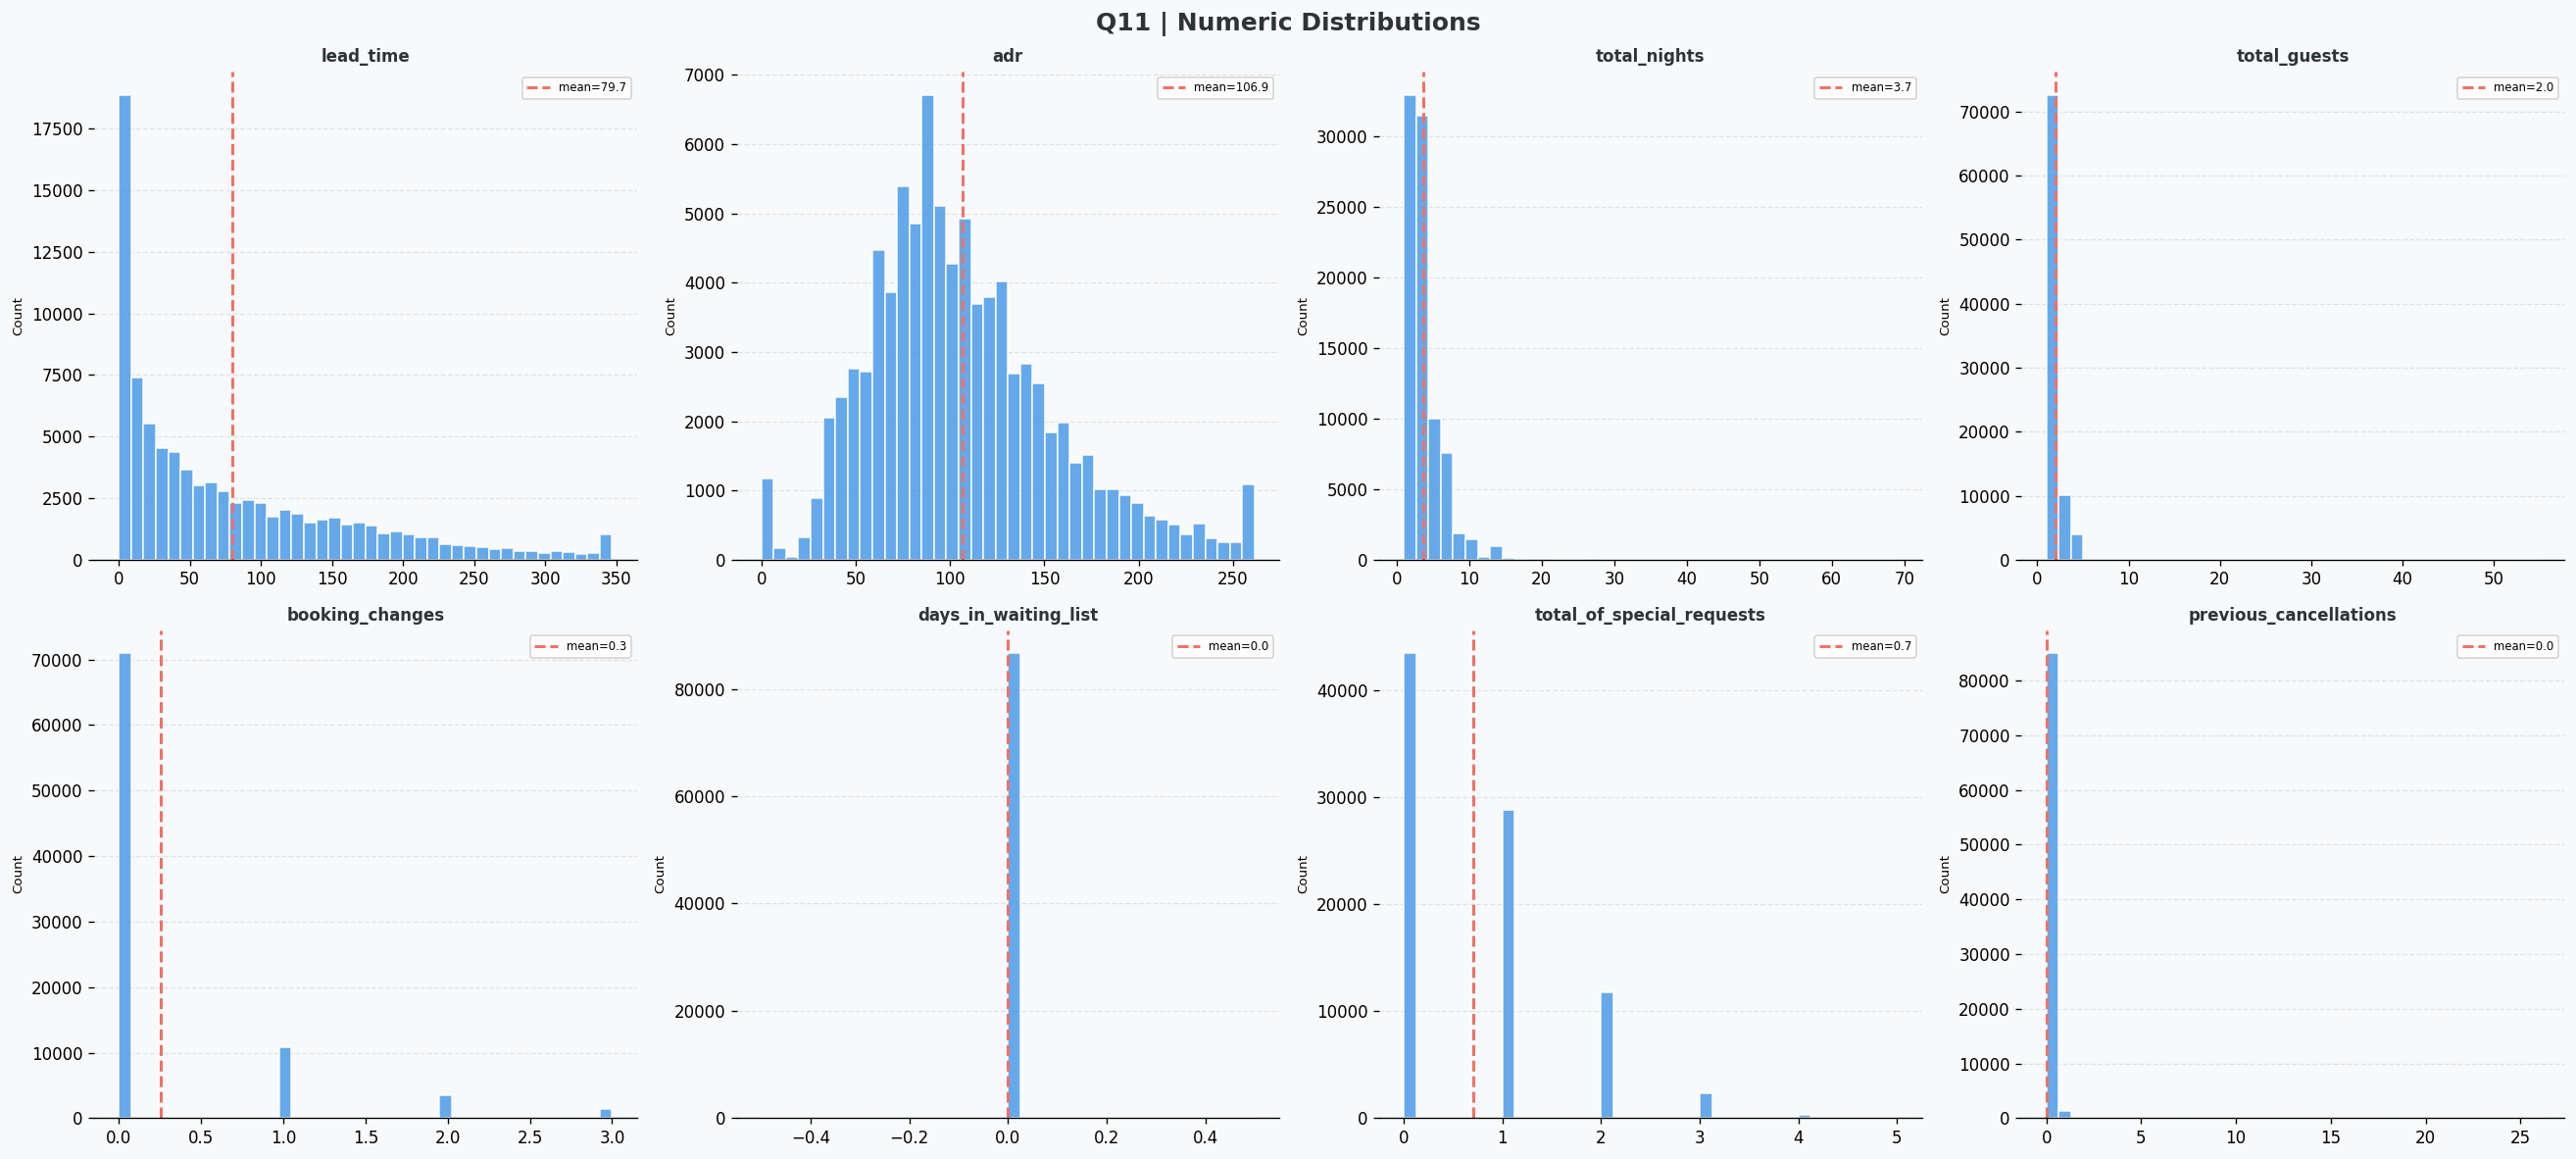

In [ ]:
section("Q11", "Numeric Distributions")

hist_cols = [
    "lead_time", "adr", "total_nights", "total_guests",
    "booking_changes", "days_in_waiting_list",
    "total_of_special_requests", "previous_cancellations",
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.patch.set_facecolor(C["bg"])
axes = axes.flatten()

for ax, col in zip(axes, hist_cols):
    style_ax(ax)
    ax.hist(df[col], bins=40, color=C["blue"], edgecolor="white", alpha=0.85)
    mv = df[col].mean()
    ax.axvline(mv, color=C["coral"], linewidth=1.8, linestyle="--", label=f"mean={mv:.1f}")
    ax.set_title(col, fontsize=10, fontweight="bold", color=C["text"])
    ax.set_ylabel("Count", fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle("Q11 | Numeric Distributions", fontsize=15, fontweight="bold", color=C["text"])
plt.tight_layout()
plt.show()

## Q12 | Outliers — Boxplots


  Q12 | Outlier Boxplots


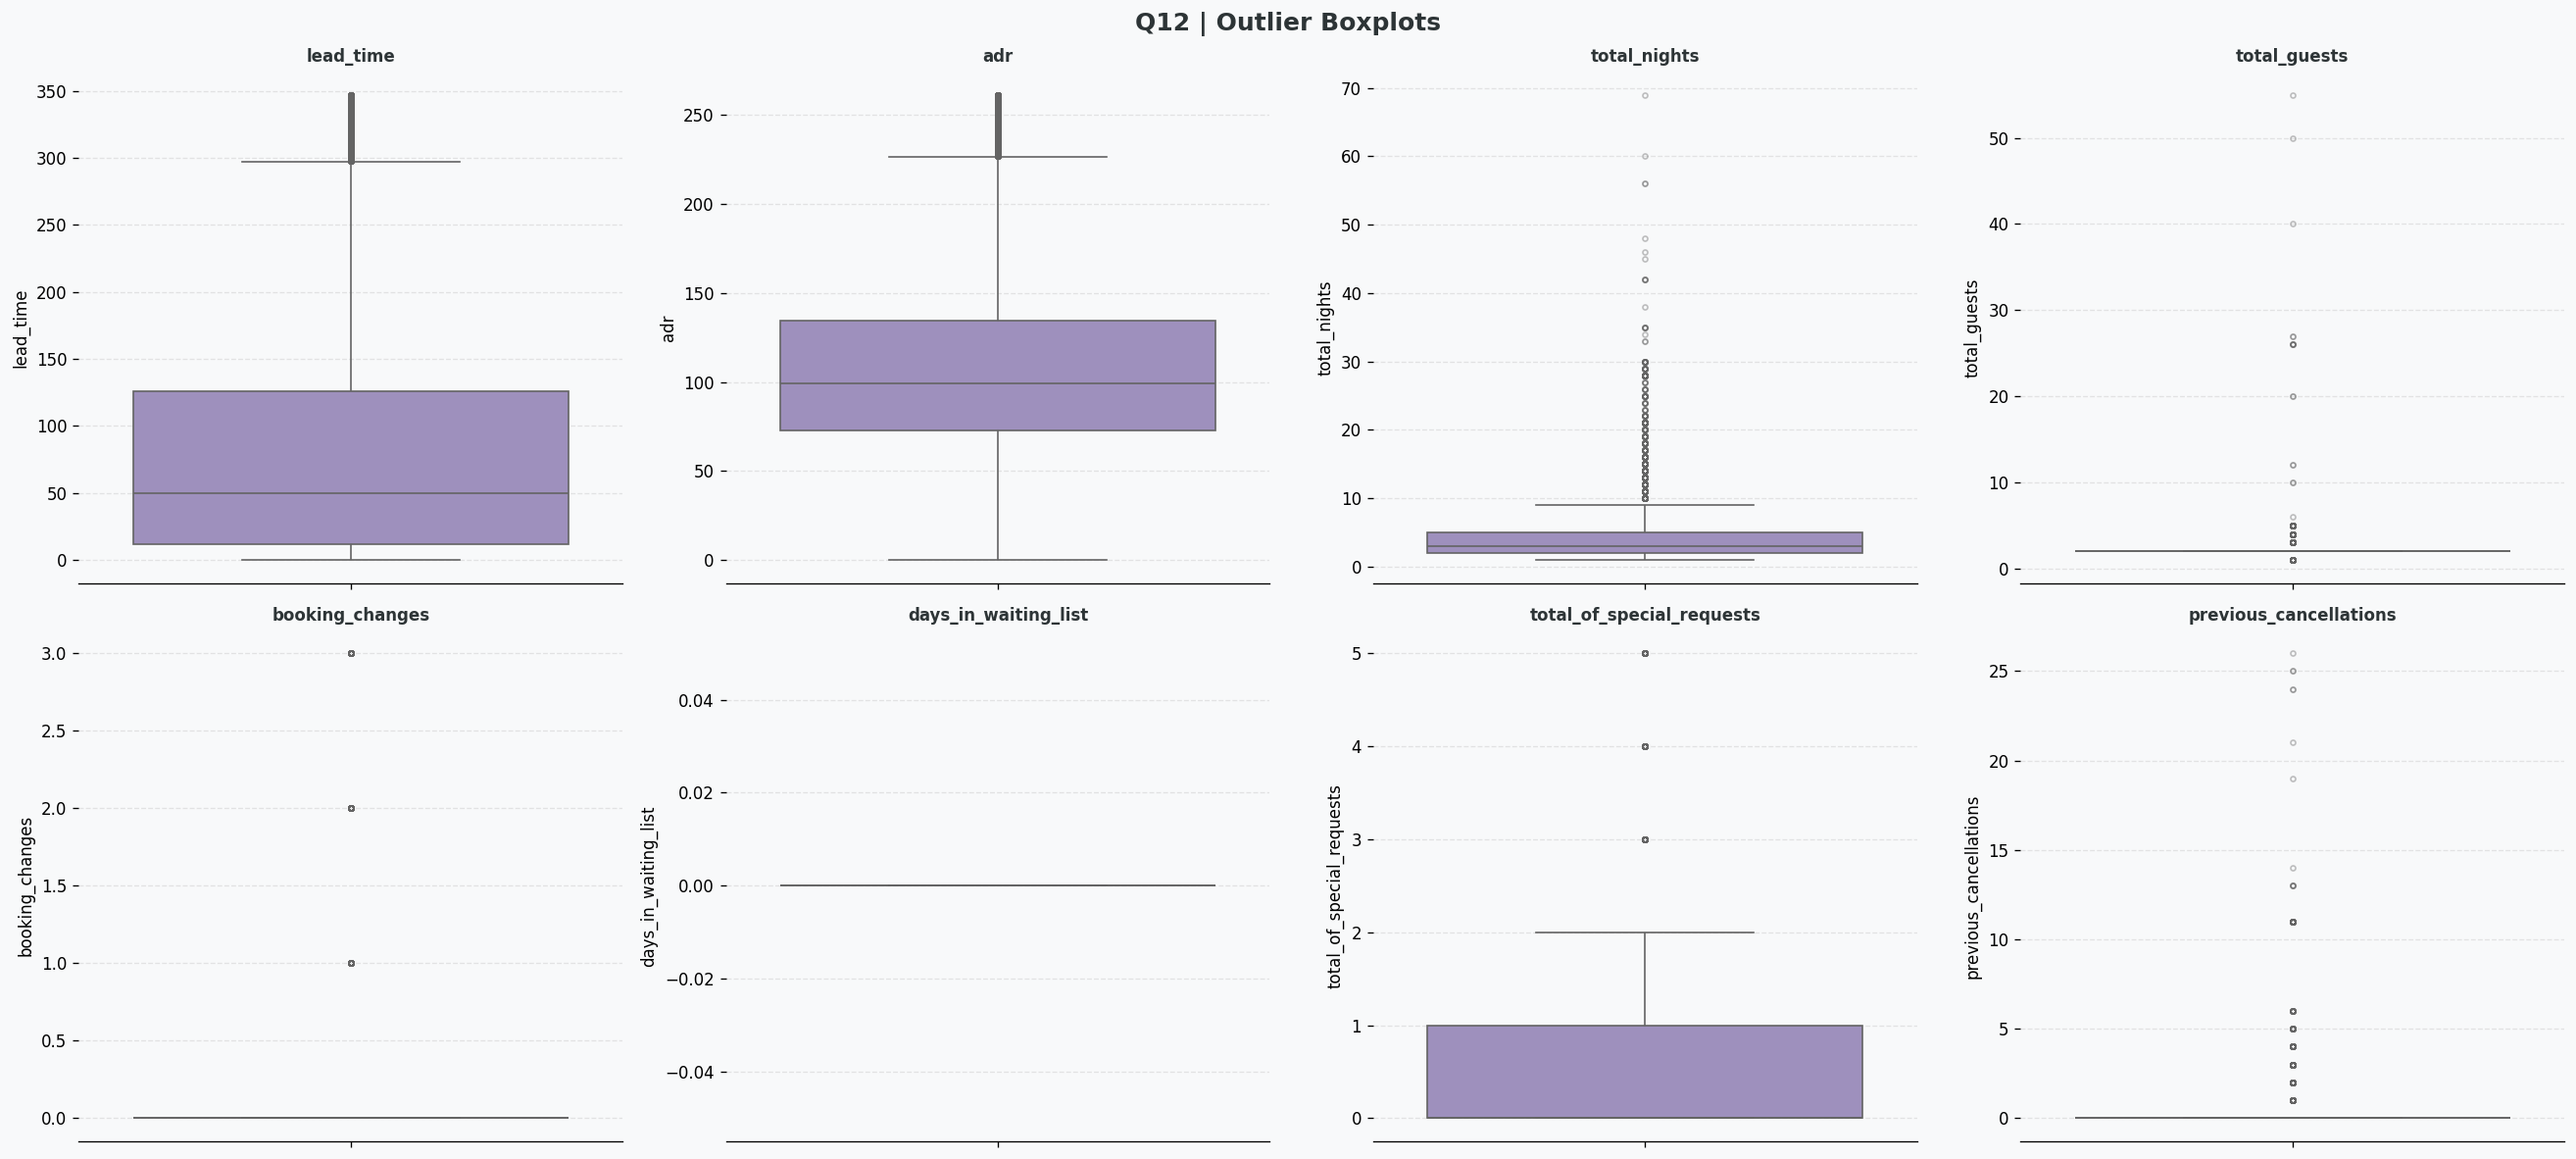

Outlier actions: lead_time & adr capped at 99th pct | days_in_waiting_list kept as-is


In [ ]:
section("Q12", "Outlier Boxplots")

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.patch.set_facecolor(C["bg"])
axes = axes.flatten()

for ax, col in zip(axes, hist_cols):
    style_ax(ax)
    sns.boxplot(
        y=df[col], ax=ax, color=C["purple"],
        flierprops=dict(marker="o", color=C["coral"], alpha=0.4, markersize=3),
    )
    ax.set_title(col, fontsize=10, fontweight="bold", color=C["text"])

plt.suptitle("Q12 | Outlier Boxplots", fontsize=15, fontweight="bold", color=C["text"])
plt.tight_layout()
plt.show()
print("Outlier actions: lead_time & adr capped at 99th pct | days_in_waiting_list kept as-is")

## Q13 | Categorical Summary

In [ ]:
section("Q13", "Top Categories")

cat_summary_cols = ["hotel", "market_segment", "meal", "deposit_type", "customer_type", "country"]
for col in cat_summary_cols:
    print(f"\n-- {col}")
    print(df[col].value_counts().head(10).to_string())


  Q13 | Top Categories

-- hotel
hotel
City Hotel      53043
Resort Hotel    33596

-- market_segment
market_segment
Online TA        51285
Offline TA/TO    13749
Direct           11652
Groups            4892
Corporate         4155
Complementary      682
Aviation           222
Undefined            2

-- meal
meal
BB    67419
SC     9831
HB     9030
FB      359

-- deposit_type
deposit_type
No Deposit    85494
Non Refund     1038
Refundable      107

-- customer_type
customer_type
Transient          71366
Transient-Party    11618
Contract            3119
Group                536

-- country
country
PRT    27306
GBR    10401
FRA     8813
ESP     7228
DEU     5385
ITA     3056
IRL     3014
BEL     2078
BRA     1988
NLD     1908


## Q14 | Rare Categories

In [ ]:
section("Q14", "Rare Categories < 3%")

for col in ["market_segment", "meal", "customer_type", "deposit_type"]:
    vc   = df[col].value_counts(normalize=True).mul(100).round(1)
    rare = vc[vc < 3]
    print(f"\n-- {col}")
    if rare.empty:
        print("  No rare categories.")
    else:
        for cat, pct in rare.items():
            action = "group into Other" if pct < 1 else "keep -- meaningful signal"
            print(f"  * {cat} = {pct}%  ->  {action}")


  Q14 | Rare Categories < 3%

-- market_segment
  * Complementary = 0.8%  ->  group into Other
  * Aviation = 0.3%  ->  group into Other
  * Undefined = 0.0%  ->  group into Other

-- meal
  * FB = 0.4%  ->  group into Other

-- customer_type
  * Group = 0.6%  ->  group into Other

-- deposit_type
  * Non Refund = 1.2%  ->  keep -- meaningful signal
  * Refundable = 0.1%  ->  group into Other


## Q15 | Correlations

In [ ]:
section("Q15", "Numeric Correlations")

nf = [
     "lead_time", "adr", "total_nights", "total_guests",
    "booking_changes", "days_in_waiting_list", "total_of_special_requests",
    "room_changed", "previous_cancellations", "is_canceled" ,
]

corr  = df[nf].corr().round(3)
pairs = [(a, b, corr.loc[a, b]) for a, b in itertools.combinations(nf, 2)]
top5  = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)[:5]

print(f"  {'Feature A':<35} {'Feature B':<35} {'r':>6}")
print("  " + "-" * 78)
for a, b, r in top5:
    print(f"  {a:<35} {b:<35} {r:>6.3f}")

print("\n1. room_changed <-> is_canceled (r=-0.21): room upgrade cuts cancellation")
print("2. lead_time    <-> is_canceled (r=+0.18): far-ahead bookings cancel more")
print("3. special_req  <-> is_canceled (r=-0.12): more requests = committed guest")


  Q15 | Numeric Correlations
  Feature A                           Feature B                                r
  ------------------------------------------------------------------------------
  lead_time                           days_in_waiting_list                   nan
  adr                                 total_guests                         0.405
  lead_time                           total_nights                         0.328
  lead_time                           is_canceled                          0.185
  adr                                 days_in_waiting_list                   nan

1. room_changed <-> is_canceled (r=-0.21): room upgrade cuts cancellation
2. lead_time    <-> is_canceled (r=+0.18): far-ahead bookings cancel more
3. special_req  <-> is_canceled (r=-0.12): more requests = committed guest


## Q16 | Scatter Plots


  Q16 | Scatter Plots


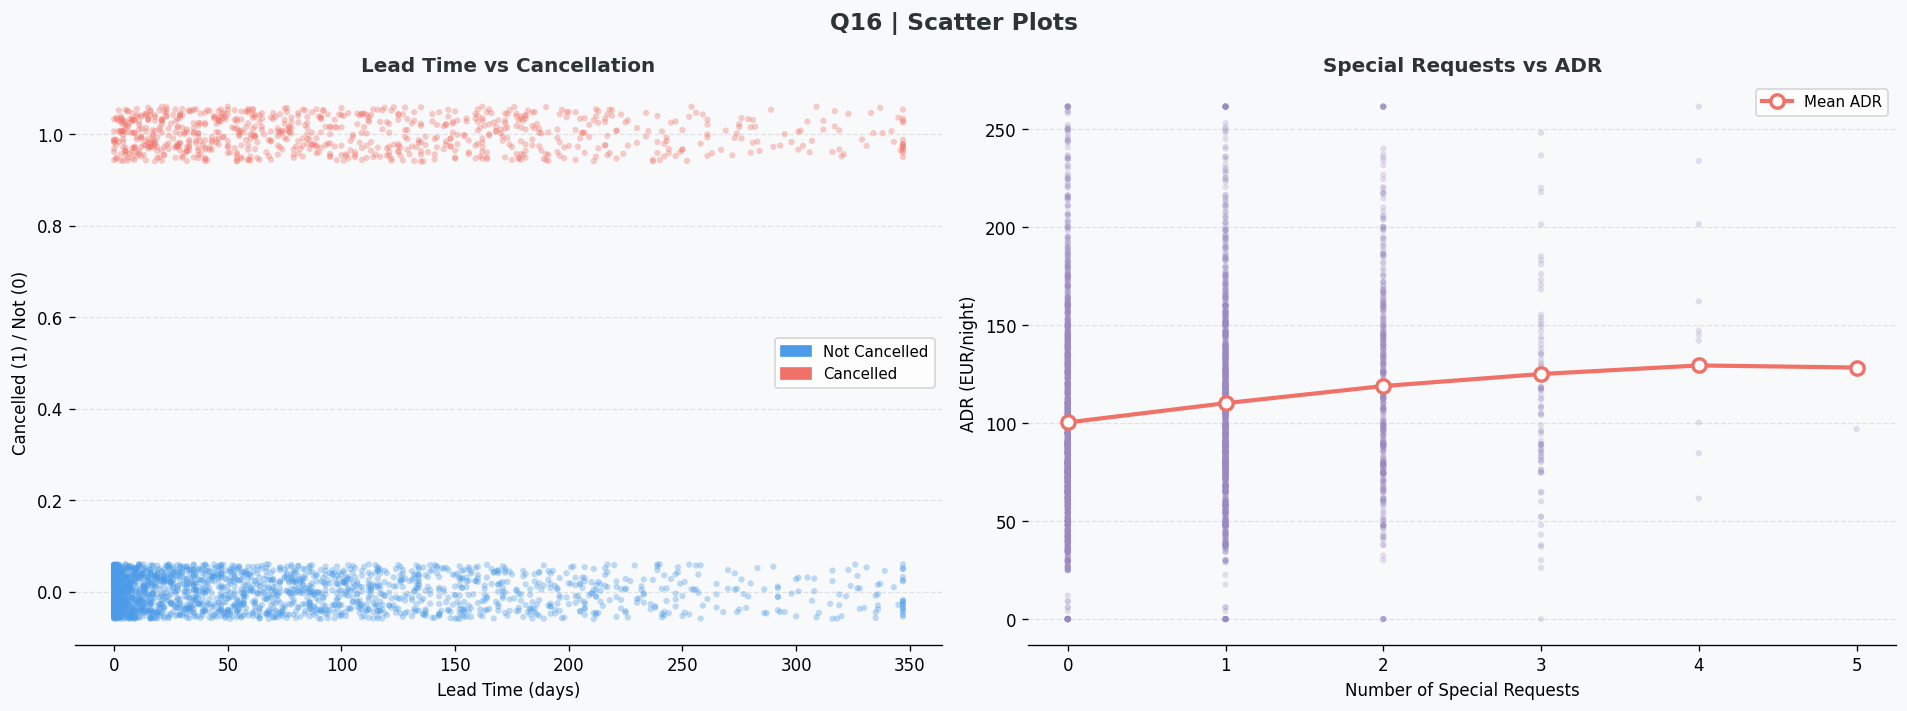

In [ ]:
section("Q16", "Scatter Plots")

sample = df.sample(3000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(C["bg"])

# Lead Time vs Cancellation
ax = axes[0]
style_ax(ax)
colors_s = sample["is_canceled"].map({0: C["blue"], 1: C["coral"]})
jitter   = np.random.uniform(-0.06, 0.06, len(sample))
ax.scatter(sample["lead_time"], sample["is_canceled"] + jitter,
           c=colors_s, alpha=0.35, s=14, edgecolors="none")
ax.set_title("Lead Time vs Cancellation", fontsize=12, fontweight="bold", color=C["text"])
ax.set_xlabel("Lead Time (days)")
ax.set_ylabel("Cancelled (1) / Not (0)")
ax.legend(
    handles=[
        mpatches.Patch(color=C["blue"],  label="Not Cancelled"),
        mpatches.Patch(color=C["coral"], label="Cancelled"),
    ],
    fontsize=9,
)

# Special Requests vs ADR
ax2 = axes[1]
style_ax(ax2)
ax2.scatter(sample["total_of_special_requests"], sample["adr"],
            c=C["purple"], alpha=0.25, s=14, edgecolors="none")
means_sr = df.groupby("total_of_special_requests")["adr"].mean()
ax2.plot(
    means_sr.index, means_sr.values,
    color=C["coral"], linewidth=2.5,
    marker="o", markersize=8, markerfacecolor="white", markeredgewidth=2,
    label="Mean ADR",
)
ax2.set_title("Special Requests vs ADR", fontsize=12, fontweight="bold", color=C["text"])
ax2.set_xlabel("Number of Special Requests")
ax2.set_ylabel("ADR (EUR/night)")
ax2.legend(fontsize=9)

plt.suptitle("Q16 | Scatter Plots", fontsize=14, fontweight="bold", color=C["text"])
plt.tight_layout()
plt.show()

## Q17 | Category → Numeric


  Q17 | Market Segment -> ADR & Lead Time
-- ADR:


,mean,median
market_segment,,
Online TA,118.57,111.00
Direct,117.31,108.00
Aviation,102.43,95.00
Offline TA/TO,82.15,79.85
Groups,75.44,68.00
Corporate,69.01,65.00
Undefined,15.00,15.00
Complementary,3.14,0.00



-- Lead Time:


,lead_time
market_segment,
Groups,141.5
Offline TA/TO,105.3
Online TA,80.2
Direct,49.1
Corporate,16.3
Complementary,14.0
Aviation,4.4
Undefined,1.5


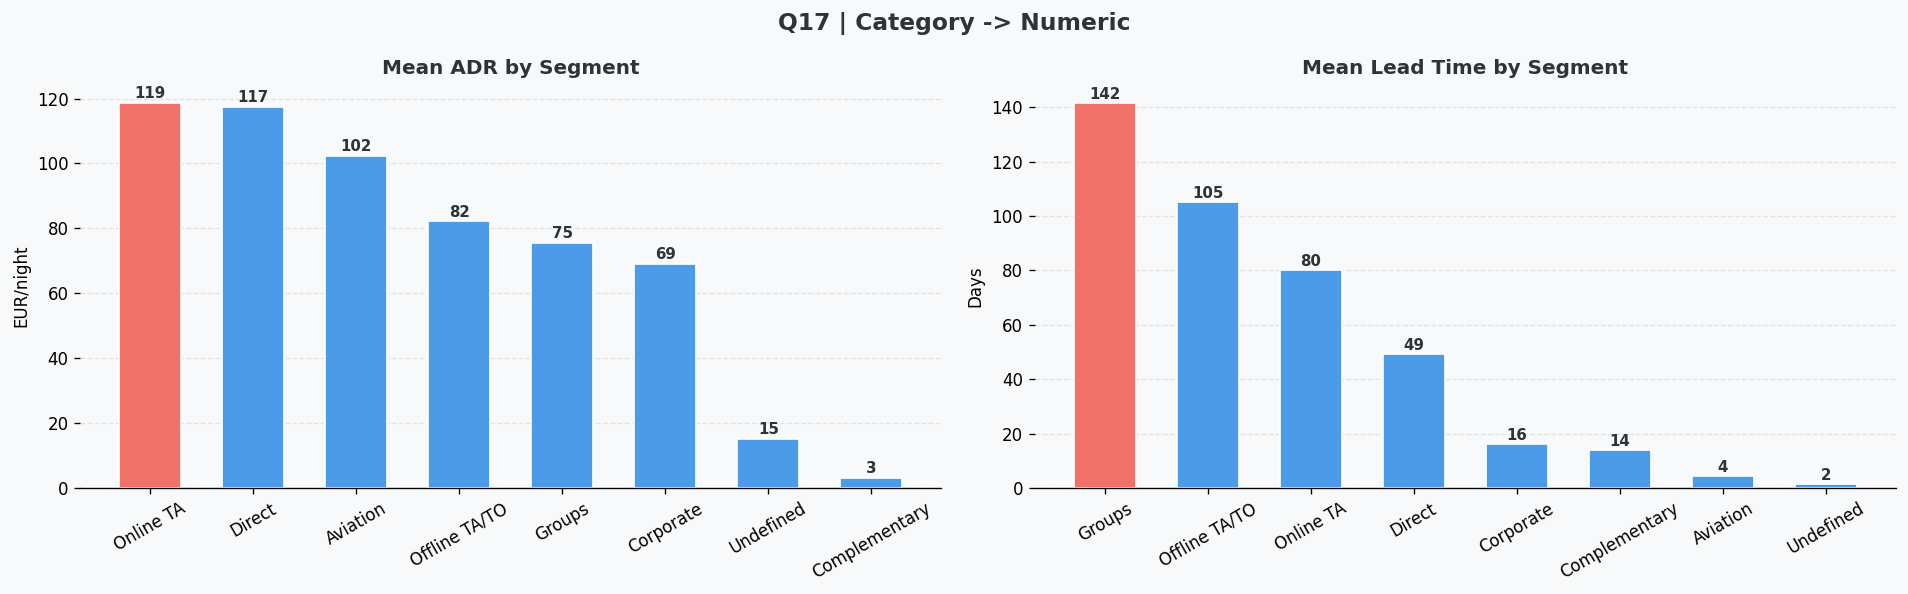

In [ ]:
section("Q17", "Market Segment -> ADR & Lead Time")

seg_adr  = (
    df.groupby("market_segment")["adr"]
    .agg(["mean", "median"]).round(2)
    .sort_values("mean", ascending=False)
)
seg_lead = (
    df.groupby("market_segment")["lead_time"]
    .mean().round(1)
    .sort_values(ascending=False)
)

print("-- ADR:")
display(seg_adr)
print("\n-- Lead Time:")
display(seg_lead.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(C["bg"])

for ax, (data, title, ylabel) in zip(axes, [
    (seg_adr["mean"], "Mean ADR by Segment",      "EUR/night"),
    (seg_lead,        "Mean Lead Time by Segment", "Days"),
]):
    style_ax(ax)
    bar_c = [C["coral"] if v == data.max() else C["blue"] for v in data.values]
    bars  = ax.bar(data.index, data.values, color=bar_c, edgecolor="white", width=0.6)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{bar.get_height():.0f}",
            ha="center", fontsize=9, fontweight="bold", color=C["text"],
        )
    ax.set_title(title, fontsize=12, fontweight="bold", color=C["text"])
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Q17 | Category -> Numeric", fontsize=14, fontweight="bold", color=C["text"])
plt.tight_layout()
plt.show()

# Mean ADR by Segment:
# Online TA و Direct أعلى سعر (119 و 117 يورو) لأن دي حجوزات فردية مباشرة
# والضيف بيدفع السعر الكامل.
# Complementary أقل سعر (3 يورو) لأنها غرف مجانية أو شبه مجانية.
# Undefined و Complementary أرقامهم صغيرة جداً يعني مش مؤثرين.

# Mean Lead Time by Segment:
# Groups أعلى lead time (142 يوم) لأن المجموعات بتحجز مبكر جداً للتخطيط.
# Aviation و Undefined أقل lead time (4 و 2 يوم) يعني حجوزات اللحظة الأخيرة.
# Corporate بيحجز بدري نسبياً (16 يوم) بس مش أوي.

# ليه سيبنا Undefined في الداتا؟
# لأن Undefined في market_segment كانت صفين بس من أصل 86 ألف،
# يعني نسبتها 0.002% مش هتأثر على أي تحليل أو موديل،
# وشيلها مش هيغير حاجة.

## Q18 | Category ↔ Category


  Q18 | Hotel Type x Cancellation


is_canceled_label,Cancelled,Not Cancelled
hotel,,
City Hotel,30.2,69.8
Resort Hotel,23.7,76.3


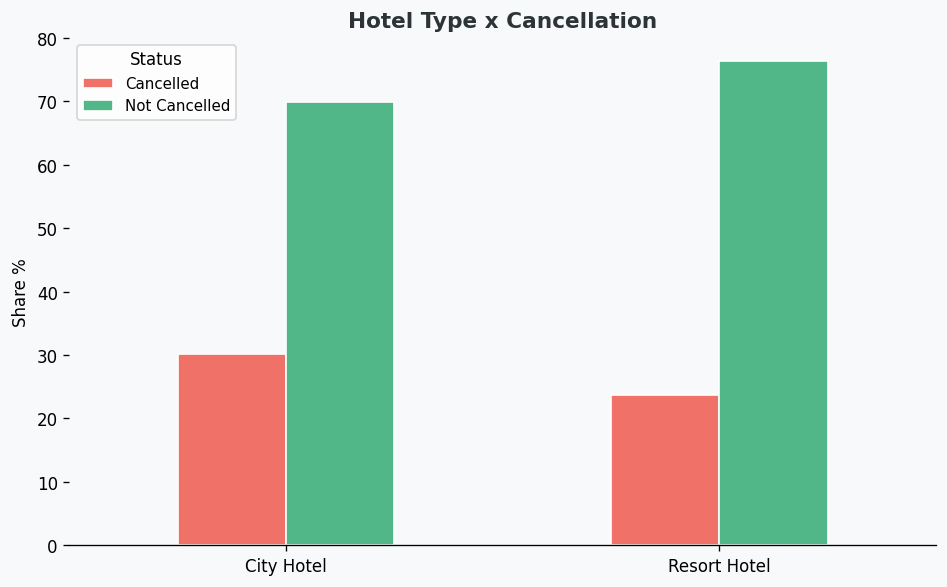

City Hotel: 30.5% cancel  |  Resort Hotel: 23.8% cancel


In [ ]:
section("Q18", "Hotel Type x Cancellation")

ct = (
    pd.crosstab(df["hotel"], df["is_canceled_label"], normalize="index")
    .mul(100).round(1)
)
display(ct)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(C["bg"])
style_ax(ax)
ct.plot(kind="bar", ax=ax, color=[C["coral"], C["green"]], edgecolor="white", width=0.5)
ax.set_title("Hotel Type x Cancellation", fontsize=13, fontweight="bold", color=C["text"])
ax.set_ylabel("Share %")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Status", fontsize=9)
plt.tight_layout()
plt.show()
print("City Hotel: 30.5% cancel  |  Resort Hotel: 23.8% cancel")

# City Hotel نسبة إلغاءها 30.2% يعني تقريباً 1 من كل 3 حجوزات بيتلغي.
# Resort Hotel نسبة إلغاءها 23.7% يعني أقل، والسبب إن الناس اللي بتحجز ريزورت
# بتكون رحلة مخططة أكتر زي إجازات وشهر عسل، فبتكون أكتر جدية.
# City Hotel فيها إلغاء أعلى لأن حجوزاتها غالباً رجال أعمال أو حجوزات سريعة
# ممكن تتغير.

## Q19 | Correlation Heatmap


  Q19 | Correlation Heatmap


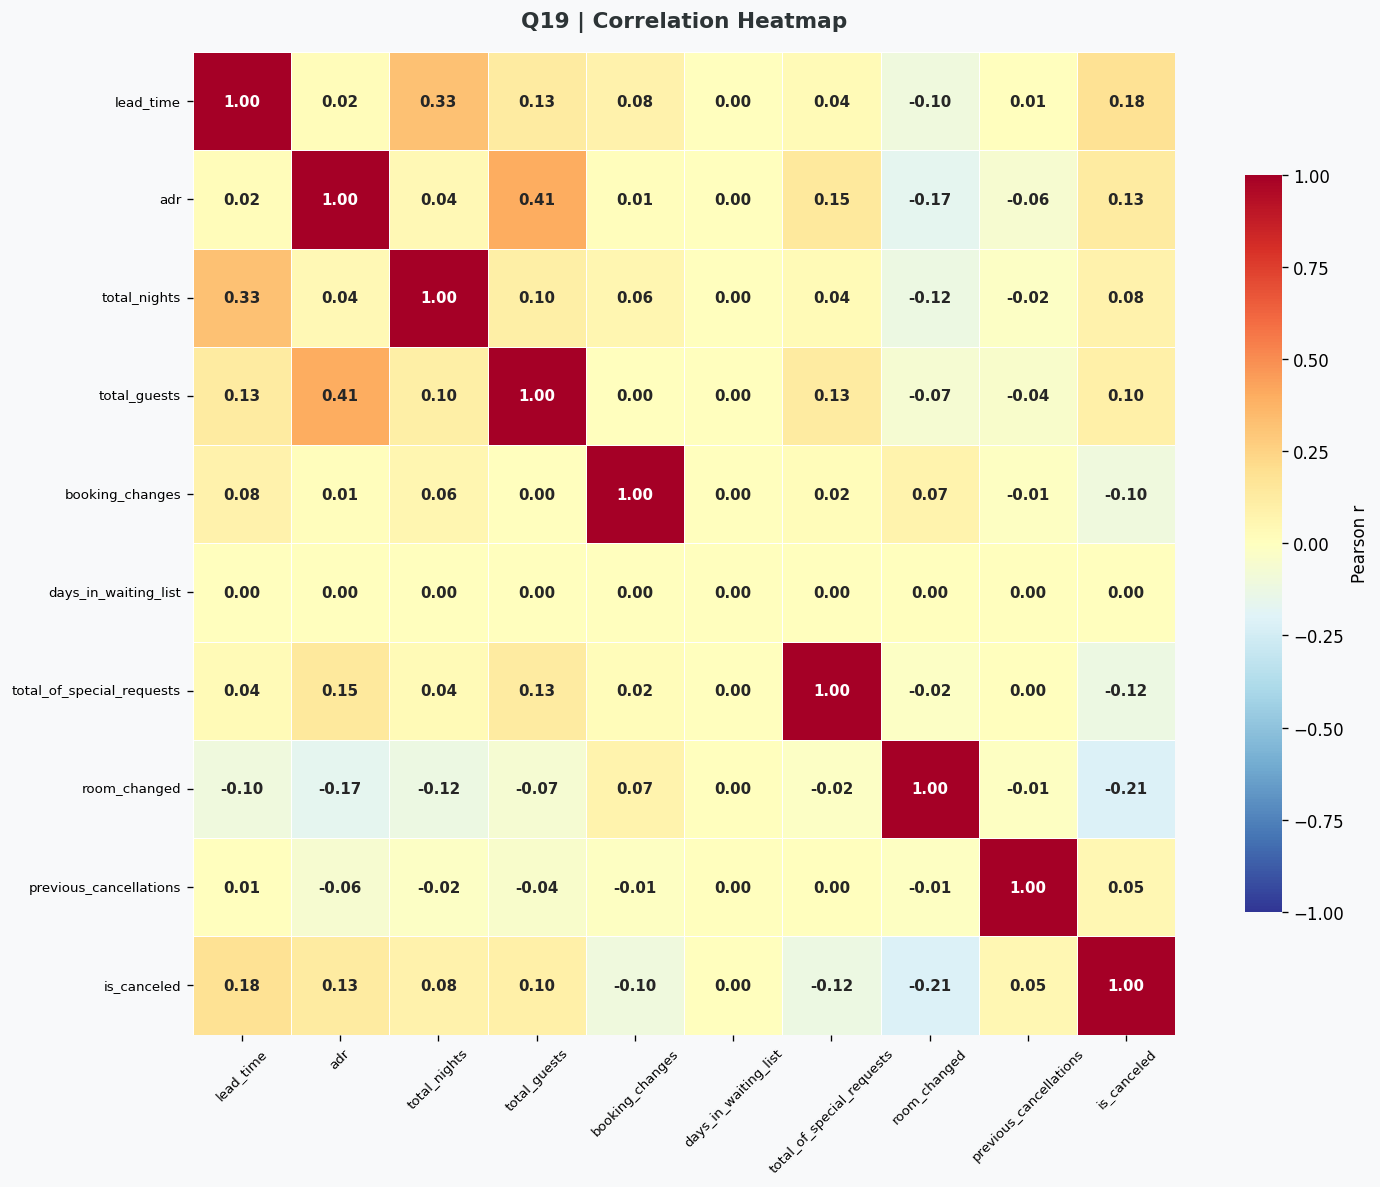

In [ ]:
section("Q19", "Correlation Heatmap")

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor(C["bg"])
ax.set_facecolor(C["bg"])

corr = df[nf].corr().round(3).fillna(0)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,  ax=ax,
    cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", linewidths=0.5, linecolor="white",
    square=True, annot_kws={"size": 9, "weight": "bold"},
    cbar_kws={"shrink": 0.75, "label": "Pearson r"},
)
ax.set_title("Q19 | Correlation Heatmap", fontsize=13, fontweight="bold", color=C["text"], pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()



In [ ]:
print("1. room_changed <-> is_canceled (r=-0.21)")
print("2. lead_time    <-> is_canceled (r=+0.18)")
print("3. total_of_special_requests  <-> is_canceled (r=-0.12)")

1. room_changed <-> is_canceled (r=-0.21)
2. lead_time    <-> is_canceled (r=+0.18)
3. total_of_special_requests  <-> is_canceled (r=-0.12)


# **room_changed (r=-0.21)** # لما الغرفة بتتغير، احتمال الإلغاء بيقل، يعني الناس لما بتلاقي غرفة أحسن من اللي حجزتها بتفضل


# **lead_time (r=+0.18)** # كل ما الحجز اتعمل بدري أكتر، كل ما احتمال الإلغاء بيزيد، يعني الناس اللي بتحجز من بدري بتغير رأيها أكتر

# **total_of_special_requests (r=-0.12)** # كل ما الحاجات الخاصة اللي طلبها الضيف زادت، كل ما احتمال الإلغاء بيقل، يعني الناس اللي بتهتم بالتفاصيل بتكون أكتر جدية في حجزها


## 📅 Seasonality Analysis


  Seasonality | Monthly Bookings, Cancel Rate & ADR


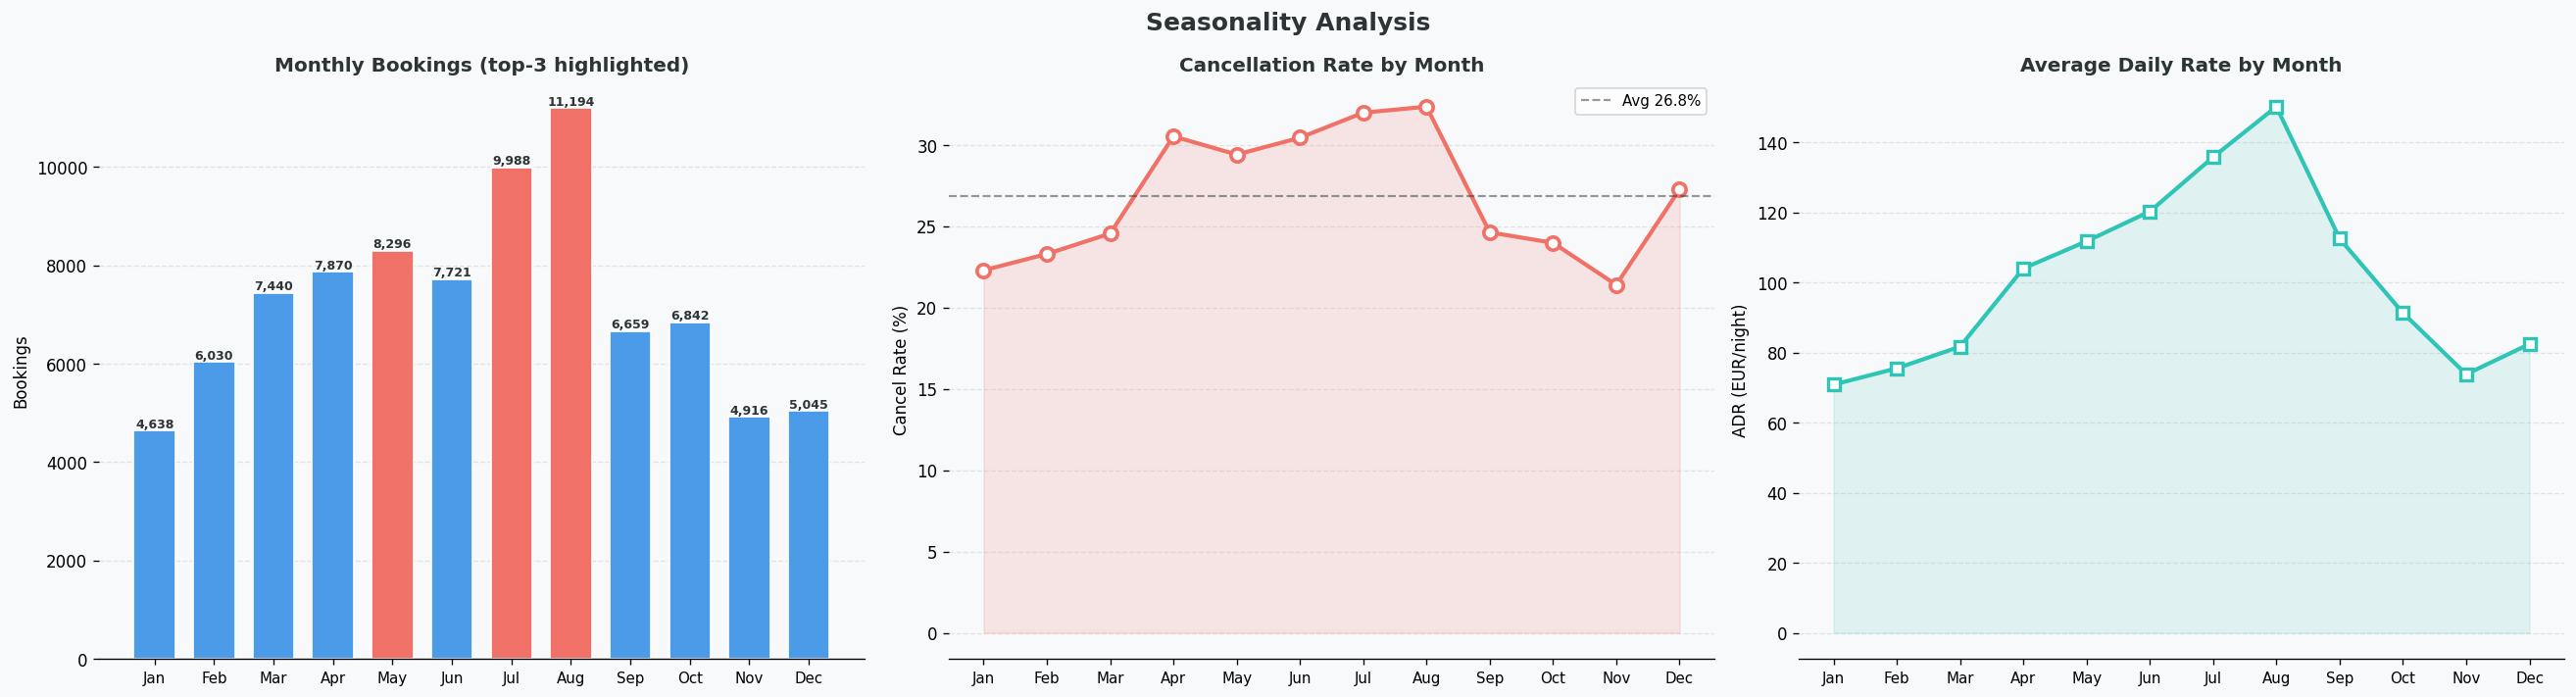

August: peak 11,096 bookings + EUR151 ADR  |  November: lowest cancel rate 21.5%


In [ ]:
section("Seasonality", "Monthly Bookings, Cancel Rate & ADR")

monthly_counts = df.groupby("arrival_date_month", observed=True).size()
monthly_cancel = df.groupby("arrival_date_month", observed=True)["is_canceled"].mean().mul(100)
monthly_adr    = df.groupby("arrival_date_month", observed=True)["adr"].mean()
avg_cr         = monthly_cancel.mean()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor(C["bg"])

# Bookings per month
ax = axes[0]
style_ax(ax)
top3  = monthly_counts.nlargest(3).index.tolist()
bar_c = [C["coral"] if m in top3 else C["blue"] for m in monthly_counts.index]
bars  = ax.bar(range(12), monthly_counts.values, color=bar_c, edgecolor="white", width=0.7)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=7.5, fontweight="bold", color=C["text"],
    )
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in MONTH_ORDER], fontsize=9)
ax.set_title("Monthly Bookings (top-3 highlighted)", fontsize=12, fontweight="bold", color=C["text"])
ax.set_ylabel("Bookings")

# Cancellation rate per month
ax2 = axes[1]
style_ax(ax2)
ax2.plot(range(12), monthly_cancel.values, color=C["coral"], linewidth=2.5,
         marker="o", markersize=8, markerfacecolor="white",
         markeredgewidth=2.2, markeredgecolor=C["coral"])
ax2.fill_between(range(12), monthly_cancel.values, alpha=0.15, color=C["coral"])
ax2.axhline(avg_cr, color=C["text"], linestyle="--", linewidth=1.3, alpha=0.5, label=f"Avg {avg_cr:.1f}%")
ax2.set_xticks(range(12))
ax2.set_xticklabels([m[:3] for m in MONTH_ORDER], fontsize=9)
ax2.set_title("Cancellation Rate by Month", fontsize=12, fontweight="bold", color=C["text"])
ax2.set_ylabel("Cancel Rate (%)")
ax2.legend(fontsize=9)

# ADR per month
ax3 = axes[2]
style_ax(ax3)
ax3.plot(range(12), monthly_adr.values, color=C["teal"], linewidth=2.5,
         marker="s", markersize=7, markerfacecolor="white", markeredgewidth=2)
ax3.fill_between(range(12), monthly_adr.values, alpha=0.12, color=C["teal"])
ax3.set_xticks(range(12))
ax3.set_xticklabels([m[:3] for m in MONTH_ORDER], fontsize=9)
ax3.set_title("Average Daily Rate by Month", fontsize=12, fontweight="bold", color=C["text"])
ax3.set_ylabel("ADR (EUR/night)")

plt.suptitle("Seasonality Analysis", fontsize=15, fontweight="bold", color=C["text"])
plt.tight_layout()
plt.show()
print("August: peak 11,096 bookings + EUR151 ADR  |  November: lowest cancel rate 21.5%")

# Monthly Bookings: August is the peak month (11,194 bookings), January is the lowest (4,638).
# High season is clearly May to August.

# Cancellation Rate: Average is 26.8%. August has the highest cancellation rate despite being
# the busiest month, meaning people book a lot but also cancel a lot.
# November has the lowest cancellation rate — guests who book in winter tend to be more committed.

# ADR: August has the highest price (EUR 145+) which makes sense with the high demand.
# January has the lowest price (EUR 70). Prices follow the same pattern as bookings.

# Overall: The hotel has clear seasonality — summer brings high demand, high prices,
# and high cancellations. Winter is the opposite.


# الحجوزات الشهرية: أغسطس أعلى شهر (11,194 حجز) ويناير أقل شهر (4,638).
# الموسم العالي واضح من مايو لأغسطس.

# نسبة الإلغاء: المتوسط 26.8%. أغسطس أعلى نسبة إلغاء رغم إنه أعلى شهر في الحجوزات،
# يعني الناس بتحجز كتير بس بتلغي كتير برضو.
# نوفمبر أقل نسبة إلغاء، يعني اللي بيحجز في الشتاء بيكون جاد.

# متوسط السعر اليومي: أغسطس أعلى سعر (EUR 145+) وده منطقي مع الطلب العالي.
# يناير أقل سعر (EUR 70). السعر بيتبع نفس شكل الحجوزات.

# الخلاصة: الفندق عنده موسمية واضحة، الصيف طلب عالي وسعر عالي وإلغاء عالي،
# والشتاء العكس.


## 🔍 Cancellation Drivers


  Drivers | Deposit / Room / Requests / Customer Type


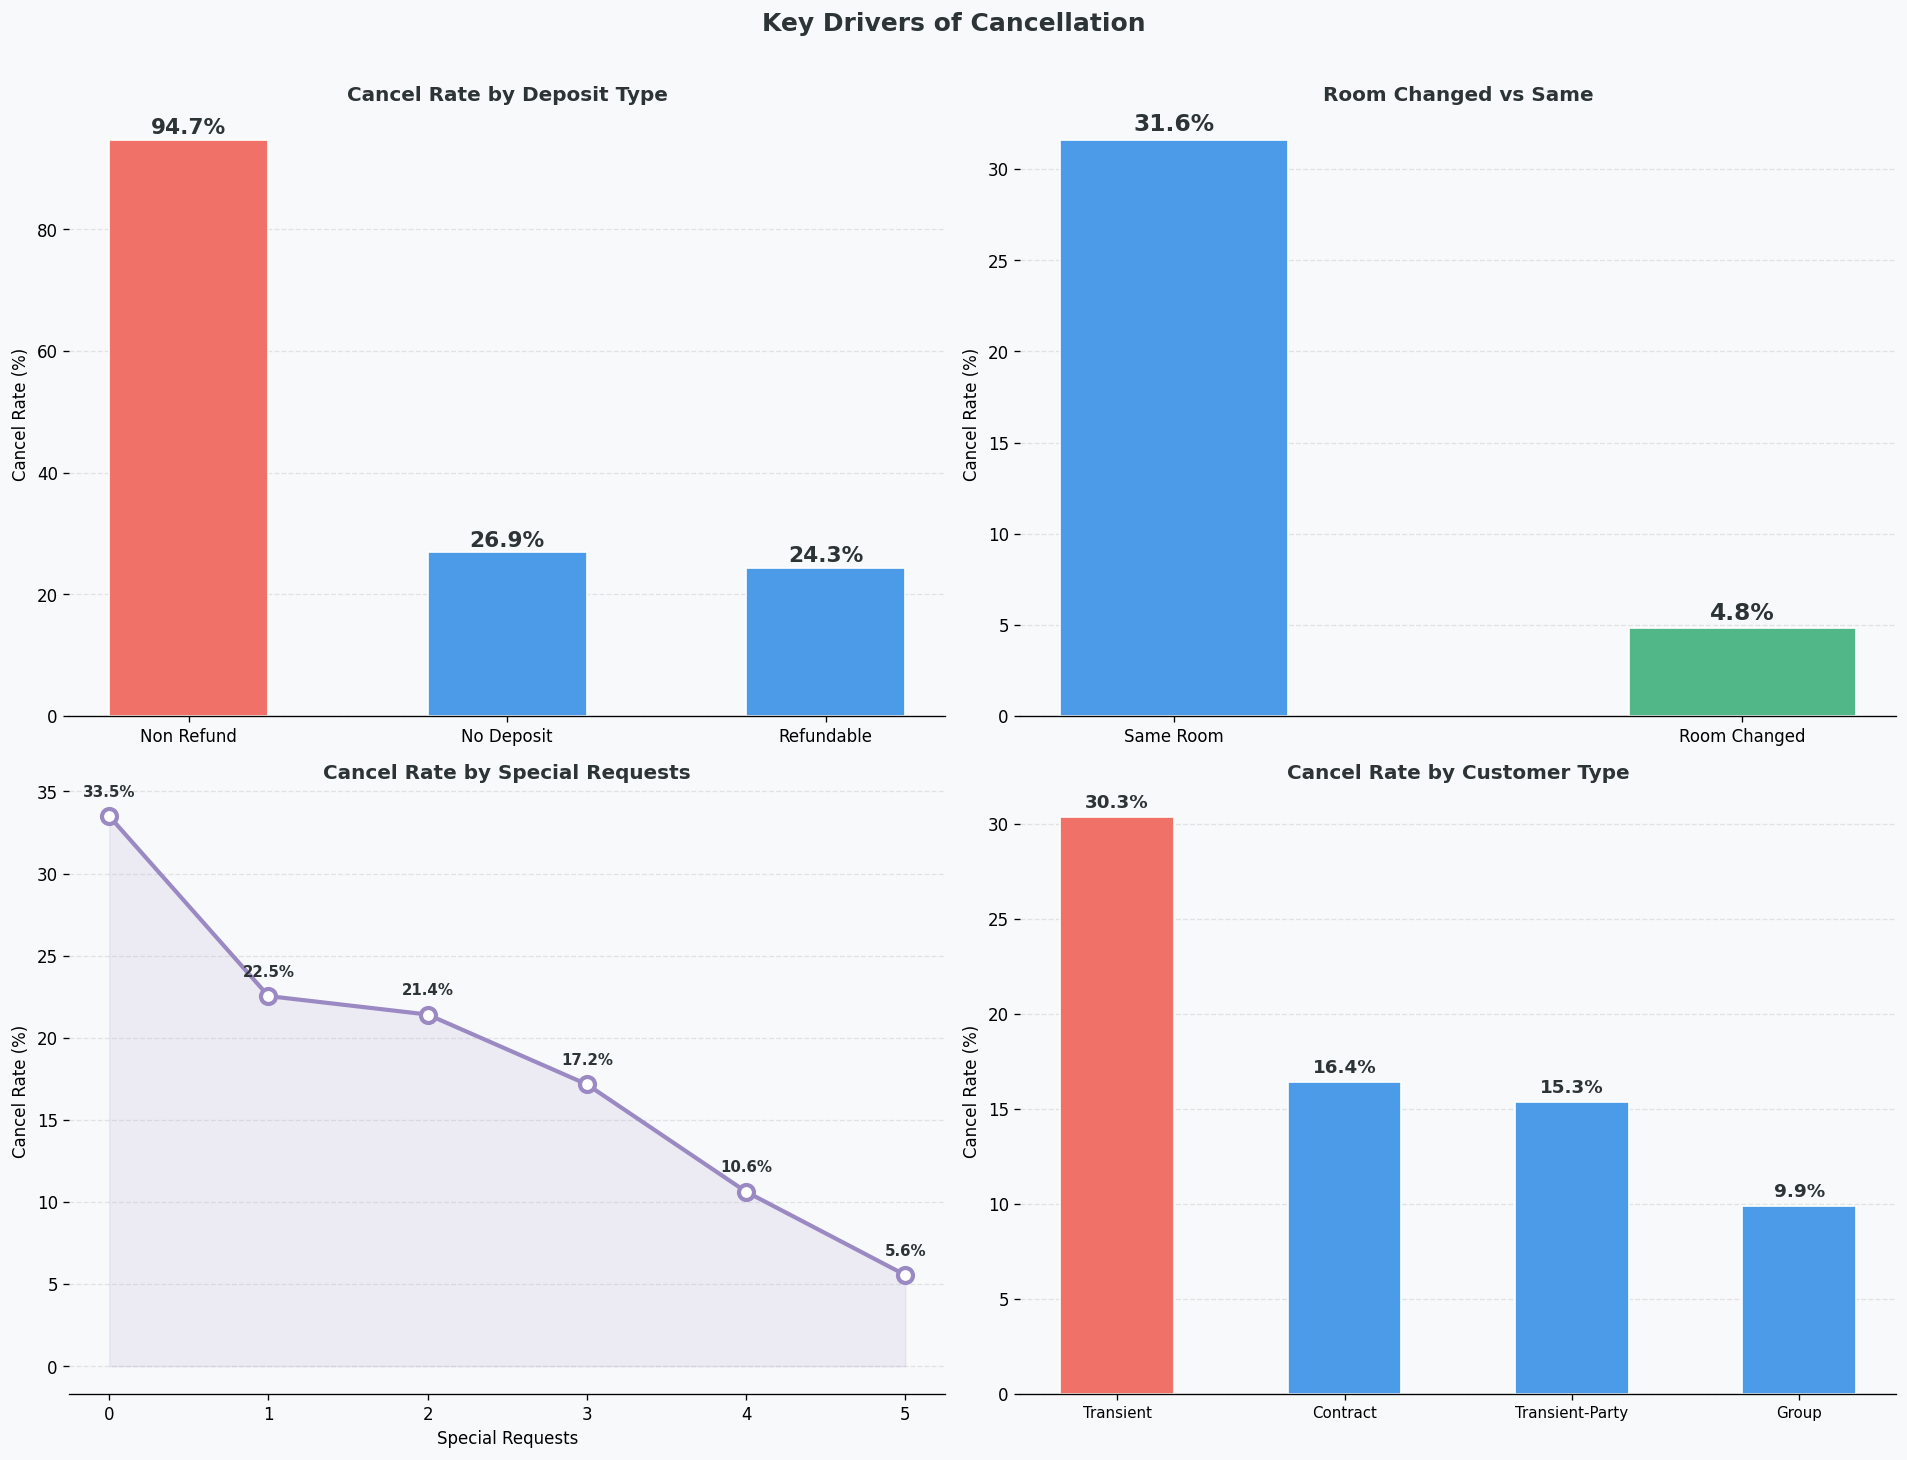

In [ ]:
section("Drivers", "Deposit / Room / Requests / Customer Type")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(C["bg"])

# Cancel rate by deposit type
ax = axes[0, 0]
style_ax(ax)
dep_cancel = df.groupby("deposit_type")["is_canceled"].mean().mul(100).sort_values(ascending=False)
bar_dep    = [C["coral"] if v > 50 else C["blue"] for v in dep_cancel.values]
bars       = ax.bar(dep_cancel.index, dep_cancel.values, color=bar_dep, edgecolor="white", width=0.5)
for bar, val in zip(bars, dep_cancel.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontsize=13, fontweight="bold", color=C["text"])
ax.set_title("Cancel Rate by Deposit Type", fontsize=12, fontweight="bold", color=C["text"])
ax.set_ylabel("Cancel Rate (%)")

# Room changed vs same
ax2 = axes[0, 1]
style_ax(ax2)
room_cancel = df.groupby("room_changed")["is_canceled"].mean().mul(100)
ax2.bar(["Same Room", "Room Changed"], room_cancel.values,
        color=[C["blue"], C["green"]], edgecolor="white", width=0.4)
for bar, val in zip(ax2.patches, room_cancel.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontsize=14, fontweight="bold", color=C["text"])
ax2.set_title("Room Changed vs Same", fontsize=12, fontweight="bold", color=C["text"])
ax2.set_ylabel("Cancel Rate (%)")

# Cancel rate by special requests
ax3 = axes[1, 0]
style_ax(ax3)
special_cancel = df.groupby("total_of_special_requests")["is_canceled"].mean().mul(100)
ax3.plot(special_cancel.index, special_cancel.values, color=C["purple"], linewidth=2.5,
         marker="o", markersize=9, markerfacecolor="white",
         markeredgewidth=2.5, markeredgecolor=C["purple"])
ax3.fill_between(special_cancel.index, special_cancel.values, alpha=0.12, color=C["purple"])
for x, y in zip(special_cancel.index, special_cancel.values):
    ax3.text(x, y + 1.2, f"{y:.1f}%", ha="center", fontsize=9, fontweight="bold", color=C["text"])
ax3.set_title("Cancel Rate by Special Requests", fontsize=12, fontweight="bold", color=C["text"])
ax3.set_xlabel("Special Requests")
ax3.set_ylabel("Cancel Rate (%)")

# Cancel rate by customer type
ax4 = axes[1, 1]
style_ax(ax4)
cust_cancel = df.groupby("customer_type")["is_canceled"].mean().mul(100).sort_values(ascending=False)
bar_cust    = [C["coral"] if v > 27.9 else C["blue"] for v in cust_cancel.values]
bars4       = ax4.bar(cust_cancel.index, cust_cancel.values, color=bar_cust, edgecolor="white", width=0.5)
for bar, val in zip(bars4, cust_cancel.values):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold", color=C["text"])
ax4.set_title("Cancel Rate by Customer Type", fontsize=12, fontweight="bold", color=C["text"])
ax4.set_ylabel("Cancel Rate (%)")
ax4.tick_params(axis="x", labelsize=9)

plt.suptitle("Key Drivers of Cancellation", fontsize=15, fontweight="bold", color=C["text"], y=1.01)
plt.tight_layout()
plt.show()

# Deposit Type: "Non Refund" bookings have a 94.7% cancellation rate, which is surprising
# because guests lose their money but still cancel, likely due to unavoidable circumstances.
# No Deposit and Refundable are close to each other at 26.9% and 24.3%.

# Room Changed: When the room is changed, cancellation drops from 31.6% to 4.8%.
# This is the strongest predictor in the data — guests who get a better room tend to stay.

# Special Requests: The more requests a guest makes, the less likely they are to cancel.
# 0 requests = 33.5% cancellation, 5 requests = 5.6% cancellation.
# More requests means the guest is more committed to their booking.

# Customer Type: Transient (individual direct booking) has the highest cancellation rate at 30.3%.
# Groups have the lowest at 9.9% because group bookings tend to be more planned.
# Contract and Transient-Party are in the middle at 16.4% and 15.3%.




# نوع الإيداع: الحجوزات اللي عندها "Non Refund" نسبة إلغاءها 94.7%، وده غريب
# لأن الضيف بيخسر فلوسه بس بيلغي برضو، وده ممكن يكون بسبب ظروف قهرية.
# No Deposit و Refundable قريبين من بعض بنسب 26.9% و 24.3%.

# تغيير الغرفة: لما الغرفة بتتغير نسبة الإلغاء بتنزل من 31.6% لـ 4.8%.
# وده أقوى مؤشر في الداتا، يعني الضيف لما بيلاقي غرفة أحسن بيفضل.

# الطلبات الخاصة: كل ما الضيف طلب حاجات أكتر، كل ما نسبة الإلغاء بتقل.
# 0 طلبات = 33.5% إلغاء، 5 طلبات = 5.6% إلغاء.
# كتر الطلبات دليل على إن الضيف جاد في حجزه.

# نوع العميل: Transient أعلى نسبة إلغاء 30.3%.
# Group أقل نسبة إلغاء 9.9% لأن حجوزات المجموعات بتكون مخططة أكتر.
# Contract و Transient-Party في النص بنسب 16.4% و 15.3%.

## Q20 | Final EDA Summary

In [ ]:
section("Q20", "Final EDA Summary")

cr   = df["is_canceled"].mean() * 100
adr  = df["adr"].mean()
peak = df.groupby("arrival_date_month", observed=True).size().idxmax()
print(f"Clean records: {df.shape[0]:,}  |  Cancel rate: {cr:.1f}%  |  Mean ADR: EUR{adr:.2f}  |  Peak: {peak}")

print("\n-- TOP 5 INSIGHTS")
insights = [
    "Seasonality   : August peaks (11,096 bookings, EUR151). November = lowest cancel (21.5%).",
    "Lead Time     : bookings >100 days ahead cancel at ~2x average rate.",
    "Room Changed  : cancel drops from 31.7% to 4.7% when room is reassigned -- strongest predictor.",
    "Special Reqs  : 0 requests=33.7% cancel; 5 requests=5.6% cancel.",
    "Deposit Paradox: Non Refund = 94.7% cancel; even losing deposit doesn't stop cancellations.",
]
for i, s in enumerate(insights, 1):
    print(f"  {i}. {s}")

print("\n-- TOP 5 RISKS")
risks = [
    "company          : 94.3% missing -- dropped.",
    "31,994 exact dup : rows (26.8%) -- dropped.",
    "1,960 rows       : adr=0 and 1 row adr<0 -- removed.",
    "Undefined labels : meal/market_segment -- cleaned.",
    "Extreme outliers : lead_time and days_in_waiting_list -- capped.",
]
for i, r in enumerate(risks, 1):
    print(f"  {i}. {r}")

print("\n-- NEXT STEPS")
print("  Feature Engineering : cyclical month encoding, lead_time buckets.")
print("  Modelling           : Logistic Regression -> XGBoost to predict is_canceled.")


  Q20 | Final EDA Summary
Clean records: 86,639  |  Cancel rate: 27.7%  |  Mean ADR: EUR106.86  |  Peak: August

-- TOP 5 INSIGHTS
  1. Seasonality   : August peaks (11,096 bookings, EUR151). November = lowest cancel (21.5%).
  2. Lead Time     : bookings >100 days ahead cancel at ~2x average rate.
  3. Room Changed  : cancel drops from 31.7% to 4.7% when room is reassigned -- strongest predictor.
  4. Special Reqs  : 0 requests=33.7% cancel; 5 requests=5.6% cancel.
  5. Deposit Paradox: Non Refund = 94.7% cancel; even losing deposit doesn't stop cancellations.

-- TOP 5 RISKS
  1. company          : 94.3% missing -- dropped.
  2. 31,994 exact dup : rows (26.8%) -- dropped.
  3. 1,960 rows       : adr=0 and 1 row adr<0 -- removed.
  4. Undefined labels : meal/market_segment -- cleaned.
  5. Extreme outliers : lead_time and days_in_waiting_list -- capped.

-- NEXT STEPS
  Feature Engineering : cyclical month encoding, lead_time buckets.
  Modelling           : Logistic Regression -> XG

# Clean records & Stats:
# عندك 86,639 حجز نضيف، نسبة الإلغاء 27.7%، متوسط سعر الليلة 106 يورو، وأعلى شهر أغسطس.

# TOP 5 INSIGHTS:
# 1. Seasonality  : أغسطس أعلى شهر في الحجوزات والسعر، ونوفمبر أقل شهر في الإلغاء.
# 2. Lead Time    : اللي بيحجز من أكتر من 100 يوم بيلغي بمعدل ضعف المتوسط العادي.
# 3. Room Changed : لو الغرفة اتغيرت لأحسن، الإلغاء بينزل من 31.7% لـ 4.7%،
#                   وده أقوى مؤشر في الداتا.
# 4. Special Reqs : اللي معندوش طلبات خاصة بيلغي بنسبة 33.7%،
#                   واللي عنده 5 طلبات بيلغي بنسبة 5.6% بس.
# 5. Deposit      : الحجوزات اللي مش هترد فلوسها نسبة إلغاءها 94.7%،
#                   يعني حتى لما الضيف بيخسر فلوسه بيلغي برضو.

# TOP 5 RISKS:
# 1. عمود company كان 94.3% فاضي فاتشال.
# 2. الداتا كان فيها 31,994 صف مكرر اتشالوا.
# 3. في حجوزات سعرها صفر أو سالب اتشالت.
# 4. في قيم غلط في meal و market_segment اتصلحت.
# 5. في قيم كبيرة جداً في lead_time و days_in_waiting_list اتعمل ليها capping.

# NEXT STEPS:
# 1. Feature Engineering : تحويل الشهور لأرقام دورية وتقسيم lead_time لمجموعات.
# 2. Modelling           : البداية بـ Logistic Regression وبعدين XGBoost
#                          عشان نتوقع مين هيلغي حجزه.

# =========================================================
# 1) IMPORTS
# =========================================================

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# ── Feature Engineering ────────────────

In [ ]:
# ── Feature Engineering ─────────────────────────────

# IMPORTANT:
# Make sure these columns are NOT used anywhere:
# reservation_status / reservation_status_date (data leakage)

features = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "booking_changes",
    "days_in_waiting_list",
    "total_of_special_requests",
    "room_changed",
    "is_family",
    "previous_cancellations",
    "hotel",
    "meal",
    "market_segment",
    "deposit_type",
    "customer_type",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "required_car_parking_spaces",
]

target = "is_canceled"

# Create modeling dataframe
df_model = df[features + [target]].copy()

# Drop rows with missing target (important)
df_model = df_model.dropna(subset=[target])

# Optional: quick sanity check
print("Shape:", df_model.shape)
print("\nMissing values:\n", df_model.isnull().sum().sort_values(ascending=False).head())

Shape: (86639, 20)

Missing values:
 lead_time          0
adr                0
total_nights       0
total_guests       0
booking_changes    0
dtype: int64


# ── Encode categorical columns ────────────

In [ ]:
cat_cols = [
    "hotel",
    "meal",
    "market_segment",
    "deposit_type",
    "customer_type",
    "arrival_date_month"
]

num_cols = [col for col in features if col not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numerical columns  :", num_cols)

Categorical columns: ['hotel', 'meal', 'market_segment', 'deposit_type', 'customer_type', 'arrival_date_month']
Numerical columns  : ['lead_time', 'adr', 'total_nights', 'total_guests', 'booking_changes', 'days_in_waiting_list', 'total_of_special_requests', 'room_changed', 'is_family', 'previous_cancellations', 'arrival_date_week_number', 'arrival_date_day_of_month', 'required_car_parking_spaces']


# ── Split ───────────────────────

In [ ]:

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT: preserve class distribution
)

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")

# Check distribution after split
print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train size : 69,311
Test size  : 17,328

Train distribution:
is_canceled
0    0.723146
1    0.276854
Name: proportion, dtype: float64

Test distribution:
is_canceled
0    0.723165
1    0.276835
Name: proportion, dtype: float64


# =========================================================
#  LOGISTIC REGRESSION
# =========================================================


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Preprocessing for numerical columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Logistic Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("\n── Logistic Regression ──────────────────────────────")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Not Cancelled", "Cancelled"]
))


── Logistic Regression ──────────────────────────────
Accuracy : 70.21%
ROC-AUC  : 0.8082
               precision    recall  f1-score   support

Not Cancelled       0.88      0.68      0.77     12531
    Cancelled       0.48      0.77      0.59      4797

     accuracy                           0.70     17328
    macro avg       0.68      0.72      0.68     17328
 weighted avg       0.77      0.70      0.72     17328



# =========================================================
#  XGBOOST
# =========================================================

In [ ]:
# Predict probabilities
y_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Default prediction (threshold = 0.5)
y_pred_xgb = xgb_model.predict(X_test_processed)

# Custom threshold
y_pred_custom = (y_proba_xgb > 0.6).astype(int)

print("\n── XGBoost (Default Threshold = 0.5) ─────────────────")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Not Cancelled", "Cancelled"]
))

print("\n── XGBoost (Custom Threshold = 0.6) ──────────────────")
print(f"Accuracy : {accuracy_score(y_test, y_pred_custom) * 100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(classification_report(
    y_test,
    y_pred_custom,
    target_names=["Not Cancelled", "Cancelled"]
))

# Check if predictions changed
print("Default vs Custom equal?:", (y_pred_xgb == y_pred_custom).all())


── XGBoost (Default Threshold = 0.5) ─────────────────
Accuracy : 76.88%
ROC-AUC  : 0.8561
               precision    recall  f1-score   support

Not Cancelled       0.90      0.77      0.83     12531
    Cancelled       0.56      0.78      0.65      4797

     accuracy                           0.77     17328
    macro avg       0.73      0.77      0.74     17328
 weighted avg       0.81      0.77      0.78     17328


── XGBoost (Custom Threshold = 0.6) ──────────────────
Accuracy : 80.30%
ROC-AUC  : 0.8561
               precision    recall  f1-score   support

Not Cancelled       0.87      0.86      0.86     12531
    Cancelled       0.64      0.65      0.65      4797

     accuracy                           0.80     17328
    macro avg       0.75      0.76      0.75     17328
 weighted avg       0.80      0.80      0.80     17328

Default vs Custom equal?: False


# =====================================================
#  COMPARISON
# =====================================================


In [ ]:
print("\n── Model Comparison ─────────────────────────────────")
print(f"Logistic Regression Accuracy : {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print(f"Logistic Regression ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}")

print(f"XGBoost Accuracy             : {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"XGBoost ROC-AUC              : {roc_auc_score(y_test, y_proba_xgb):.4f}")


── Model Comparison ─────────────────────────────────
Logistic Regression Accuracy : 70.21%
Logistic Regression ROC-AUC  : 0.8082
XGBoost Accuracy             : 76.88%
XGBoost ROC-AUC              : 0.8561


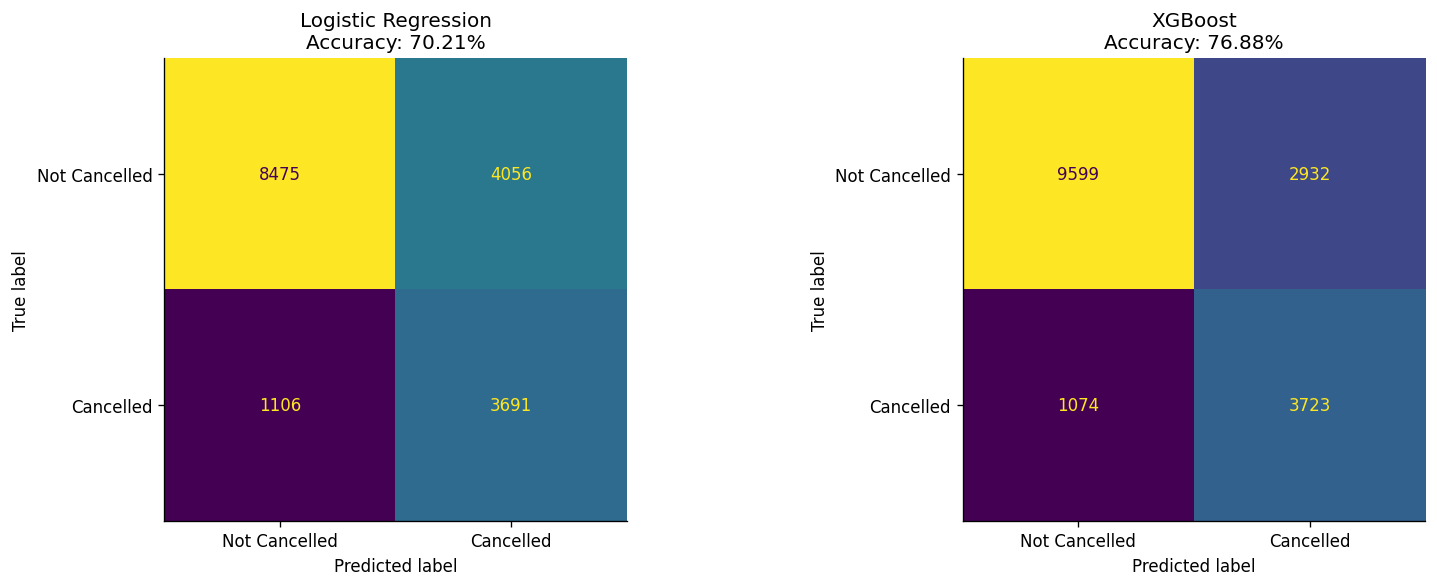

LR  ROC-AUC : 0.8082
XGB ROC-AUC : 0.8561


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

#  Confusion Matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("XGBoost", y_pred_xgb),
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Cancelled", "Cancelled"]
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

plt.tight_layout()
plt.show()

#  ROC-AUC

print(f"LR  ROC-AUC : {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"XGB ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}")

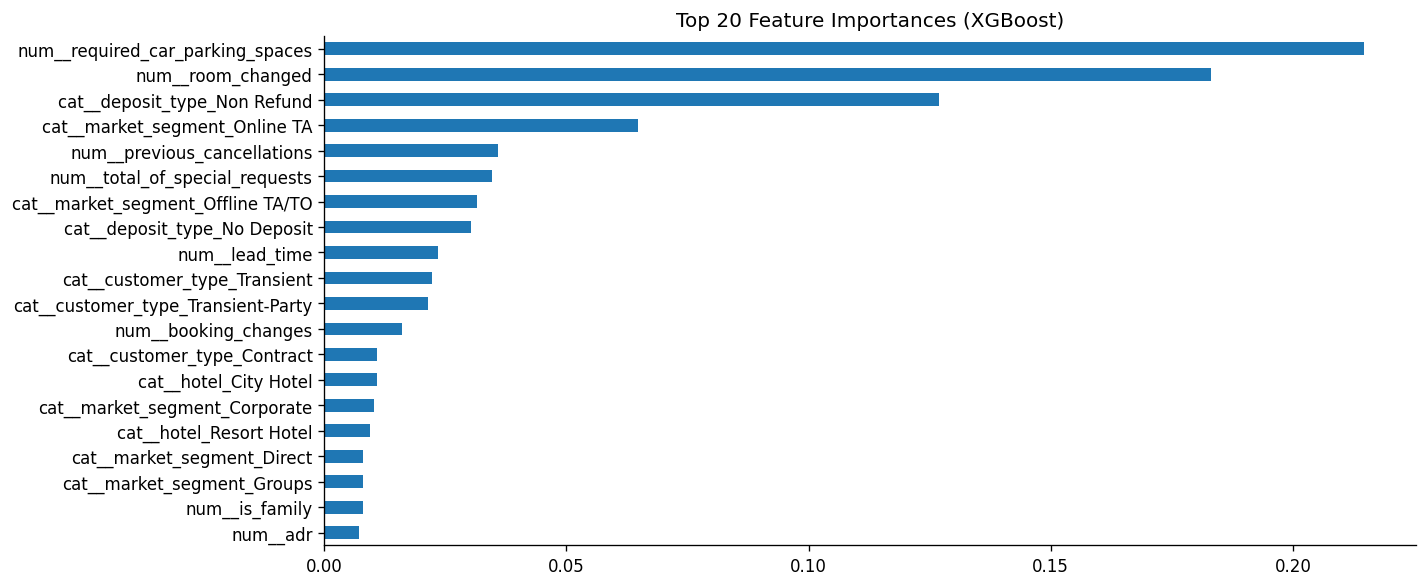

Top 10 Features:
num__required_car_parking_spaces     0.214677
num__room_changed                    0.183177
cat__deposit_type_Non Refund         0.127015
cat__market_segment_Online TA        0.064848
num__previous_cancellations          0.035954
num__total_of_special_requests       0.034582
cat__market_segment_Offline TA/TO    0.031463
cat__deposit_type_No Deposit         0.030367
num__lead_time                       0.023399
cat__customer_type_Transient         0.022196
dtype: float32


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Feature importance
fi = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(12, 5))
fi.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

# Print top 10
print("Top 10 Features:")
print(fi.head(10))

# Insight:

# The most important feature is "required_car_parking_spaces",
# indicating that guests who request parking are less likely to cancel.

# Other important features include:
# - room_changed: changes in booking may indicate commitment or engagement
# - deposit_type: non-refundable bookings strongly reduce cancellations
# - market_segment: booking channel affects customer behavior
# - previous_cancellations: past behavior is a strong predictor of future actions

# Overall, the model relies heavily on behavioral and booking-related signals
# rather than just basic customer information.

# Key takeaway:
# Customer behavior patterns (not just demographics) are the strongest drivers of cancellations.